Calibration successful with 22 images
Camera Matrix (K):
 [[1.04273871e+03 0.00000000e+00 3.11371738e+02]
 [0.00000000e+00 1.03600751e+03 2.20082475e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion Coefficients:
 [[-4.64744812e-02 -1.20396950e+00 -4.06388412e-03  3.54748701e-03
   1.27937234e+01]]


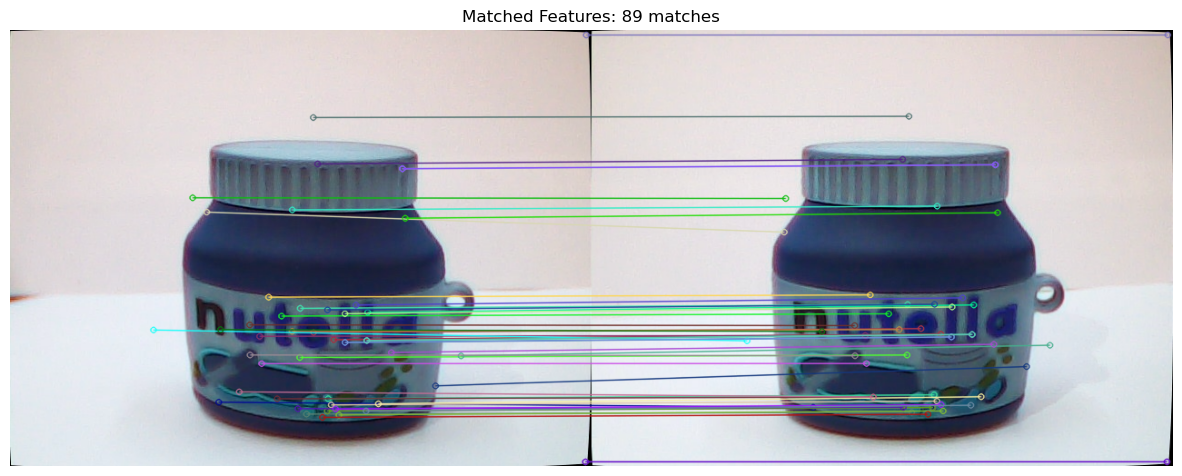


=== Geometry Estimation Results ===
Essential Matrix:
[[  -85.48695147  1097.25756771  -219.17033183]
 [-1157.51629912    -4.9799503   -417.34652418]
 [  199.23916496   400.8122596      3.20582967]]
Rotation:
[[ 0.99911187  0.04125827 -0.00855682]
 [-0.04115717  0.9990845   0.01167264]
 [ 0.00903058 -0.0113101   0.99989526]]
Translation:
[[ 0.33652783]
 [-0.18382251]
 [-0.92355742]]


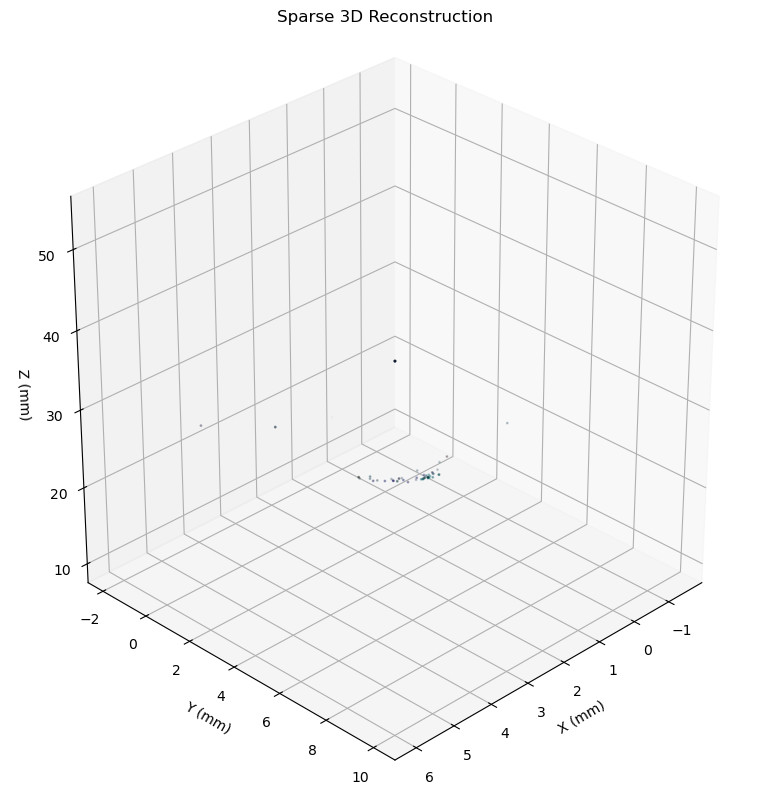

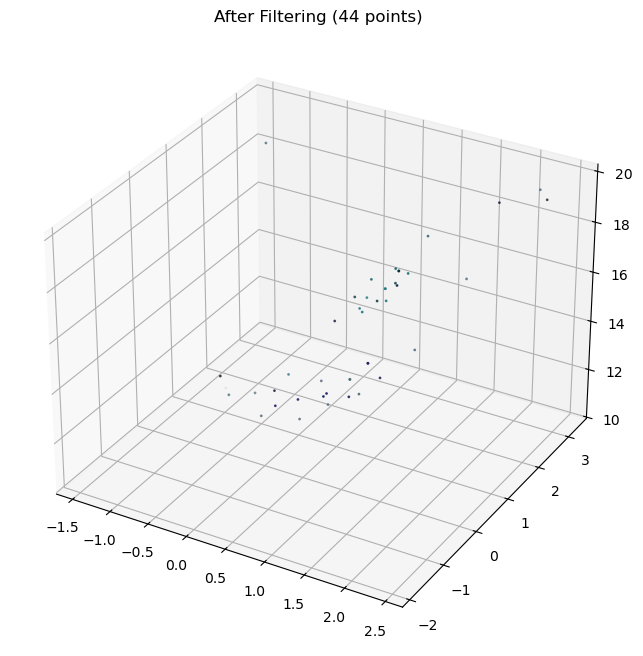

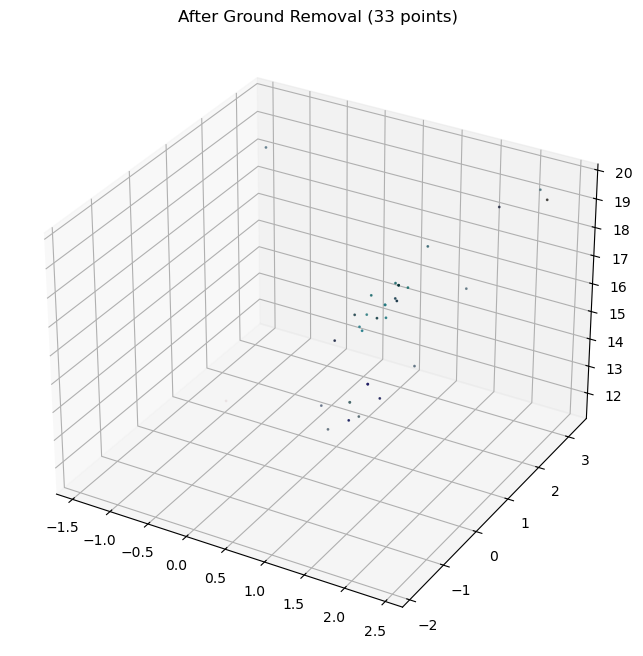

In [4]:
from modules.calibration import calibrate_camera
from modules.feat_matching import feature_detection_and_matching
from modules.stereo_rectification import rectificate_images
from modules.stereo_geometry_estimation import estimate_stereo_geometry
from modules.reconstruction import reconstruct_3d , visualize_point_cloud
from modules.filtering_refining import ultimate_post_process
import numpy as np
import cv2

# Step 1: Camera Calibration
K, dist = calibrate_camera('images/cal')
K = K.astype(np.float32)
dist = dist.astype(np.float32)

# Step 2: Load and undistort stereo images (captured with same camera from 2 poses)
left_img_path = 'images/left/4.jpg'
right_img_path = 'images/right/4.jpg'
left_img = cv2.undistort(cv2.imread(left_img_path), K, dist)
right_img = cv2.undistort(cv2.imread(right_img_path), K, dist)

# Step 3: Feature Matching
matched_img, good_matches, keypoints1, keypoints2 = feature_detection_and_matching(left_img, right_img)

# Step 4: Compute Essential Matrix and Recover Pose
E, R, T, pts1, pts2 = estimate_stereo_geometry(keypoints1, keypoints2, good_matches, K)

# Step 5: Stereo Rectification using real R, T
rect_left, rect_right, Q = rectificate_images(left_img, right_img, K, dist, R, T, return_Q=True)

# After getting pts1, pts2 from estimate_stereo_geometry
# Ensure they're in the right format:
pts1 = np.asarray(pts1, dtype=np.float32).reshape(-1, 2)
pts2 = np.asarray(pts2, dtype=np.float32).reshape(-1, 2)

# Step 6: 3D Reconstruction
points_3d, colors = reconstruct_3d(left_img, right_img, K, R, T, pts1, pts2)

# Visualize the sparse point cloud
visualize_point_cloud(points_3d, colors, "Sparse 3D Reconstruction")

# Optional: Save the point cloud
np.savez("reconstruction.npz", points=points_3d, colors=colors, K=K, R=R, T=T)

# After getting your initial reconstruction
points_3d, colors = reconstruct_3d(left_img, right_img, K, R, T, pts1, pts2)

# After reconstruction
points_3d, colors = reconstruct_3d(left_img, right_img, K, R, T, pts1, pts2)

# Process with ultimate safety
processed_points, processed_colors = ultimate_post_process(
    points_3d, 
    colors,
    remove_ground=True,
    visualize=True
)

# Save results (will work even with empty arrays)
np.savez("final_reconstruction.npz", 
         points=processed_points, 
         colors=processed_colors)



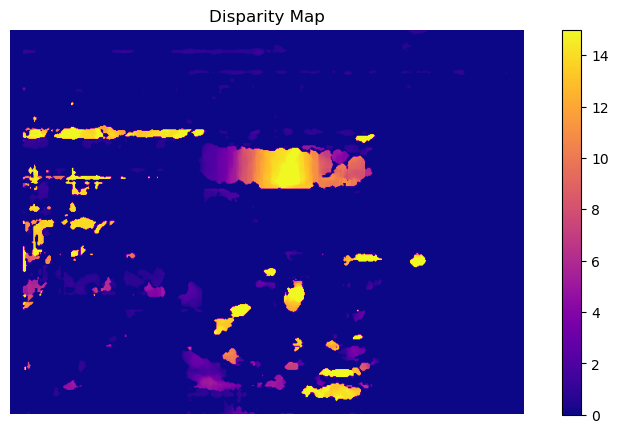

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Step 7: Compute Disparity Map
def compute_disparity_map(imgL, imgR, ndisp=16, mindis=0):
    """
    Compute disparity map from stereo images.
    """
    stereo = cv2.StereoSGBM_create(
        minDisparity=mindis,
        numDisparities=ndisp,
        blockSize=11,
        P1=8 * 3 * 11**2,
        P2=32 * 3 * 11**2,
        disp12MaxDiff=1,
        preFilterCap=63,
        uniquenessRatio=10,
        speckleWindowSize=100,
        speckleRange=32,
    )

    disparity_map = stereo.compute(imgL, imgR).astype(np.float32) / 16.0
    mask = disparity_map > 0
    disparity_map = disparity_map * mask.astype(np.float32)
    return disparity_map

# Convert images to grayscale for disparity computation
left_gray = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

# Compute the disparity map
disparity_map = compute_disparity_map(left_gray, right_gray)

# Step 8: Display the Disparity Map
plt.figure(figsize=(10, 5))
plt.imshow(disparity_map, cmap='plasma')
plt.colorbar()
plt.title('Disparity Map')
plt.axis('off')
plt.show()


=== Geometry Estimation Results ===
Essential Matrix:
[[  -85.48695147  1097.25756771  -219.17033183]
 [-1157.51629912    -4.9799503   -417.34652418]
 [  199.23916496   400.8122596      3.20582967]]
Rotation:
[[ 0.99911187  0.04125827 -0.00855682]
 [-0.04115717  0.9990845   0.01167264]
 [ 0.00903058 -0.0113101   0.99989526]]
Translation:
[[ 0.33652783]
 [-0.18382251]
 [-0.92355742]]


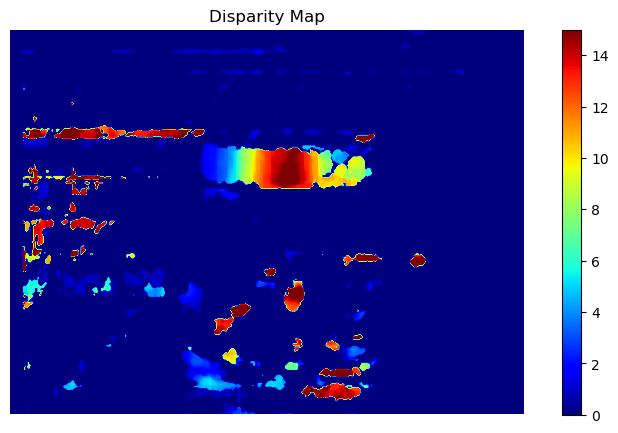

[INFO] Point cloud saved as output_point_cloud.ply


In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import open3d as o3d

from modules.stereo_rectification import rectificate_images
from modules.stereo_geometry_estimation import estimate_stereo_geometry
from modules.reconstruction import reconstruct_3d, visualize_point_cloud as vis_old

# Step 4: Estimate Stereo Geometry
E, R, T, pts1, pts2 = estimate_stereo_geometry(keypoints1, keypoints2, good_matches, K)

plt.figure(figsize=(10, 5))
plt.imshow(disparity_map, cmap='jet')
plt.colorbar()
plt.title("Disparity Map")
plt.axis('off')
plt.show()

# Step 7: Reconstruct 3D from disparity
def reconstruct_3D(disparity_map: np.ndarray, Q: np.ndarray) -> np.ndarray:
    try:
        points_3D = cv2.reprojectImageTo3D(disparity_map, Q)
        return points_3D
    except Exception as e:
        print(f"Error in reconstruct_3D: {e}")
        return None

# Step 8: Visualize 3D Point Cloud
def visualize_point_cloud(points_3D: np.ndarray, colors: np.ndarray, disparity_map: np.ndarray):
    try:
        mask = (
            ~np.isnan(points_3D[:, :, 0]) &
            ~np.isinf(points_3D[:, :, 0]) &
            (disparity_map > 0)
        )
        if not np.any(mask):
            print("Warning: No valid points to visualize.")
            return
        valid_points = points_3D[mask]
        valid_colors = colors[mask]

        point_cloud = o3d.geometry.PointCloud()
        point_cloud.points = o3d.utility.Vector3dVector(valid_points)
        point_cloud.colors = o3d.utility.Vector3dVector(valid_colors / 255.0)
        o3d.visualization.draw_geometries([point_cloud])
    except Exception as e:
        print(f"Error in visualize_point_cloud: {e}")

# Step 9: Use new functions
points_3D = reconstruct_3D(disparity_map, Q)
visualize_point_cloud(points_3D, rect_left, disparity_map)

# Optional: Save point cloud
mask = disparity_map > 0
flat_points = points_3D[mask].reshape(-1, 3)
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(flat_points)
o3d.io.write_point_cloud("output_point_cloud.ply", pcd)
print("[INFO] Point cloud saved as output_point_cloud.ply")
